In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from sklearn.model_selection import train_test_split 

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.optimizer import SGD

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

param_grid_dnn = {
    'max_words': [2000, 3000, 3500],
    'hidden_neurons': [64, 128, 164],
    'learning_rate': [0.05, 0.1],
    'epochs': [200, 250]
}

resultados_dnn = []

print("=== A Iniciar Grid Search: DNN ===")
for params in build_grid(param_grid_dnn):
    print(f"\nA testar: {params}")
    inicio = time.time()

    num_classes = len(label_map)
    y_train_oh = np.eye(num_classes)[y_train.values]
    y_val_oh = np.eye(num_classes)[y_val.values]
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = NeuralNetwork()
    model.add(DenseLayer(input_size=params['max_words'], output_size=params['hidden_neurons']))
    model.add(ReLUActivation())
    model.add(DenseLayer(input_size=params['hidden_neurons'], output_size=6))
    model.add(SoftmaxActivation())
    
    model.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=params['learning_rate']))
    
    history = model.fit(X_tr, y_train_oh, epochs=params['epochs'], val_data=(X_te, y_val_oh))
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_dnn.append({
        'Max Words': params['max_words'],
        'Hidden Neurons': params['hidden_neurons'],
        'Learning Rate': params['learning_rate'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_dnn = pd.DataFrame(resultados_dnn).sort_values(by='Val Accuracy', ascending=False)
display(df_grid_dnn)

A treinar o Modelo DNN Final...
Epoch 10/150 | Loss: 0.6054 Acc: 0.7960 | Val Loss: 0.6259 Val Acc: 0.7831
Epoch 20/150 | Loss: 0.2905 Acc: 0.9043 | Val Loss: 0.3770 Val Acc: 0.8726
Epoch 30/150 | Loss: 0.1582 Acc: 0.9591 | Val Loss: 0.2629 Val Acc: 0.9173
Epoch 40/150 | Loss: 0.0981 Acc: 0.9774 | Val Loss: 0.2283 Val Acc: 0.9270
Epoch 50/150 | Loss: 0.0649 Acc: 0.9907 | Val Loss: 0.2018 Val Acc: 0.9339
Epoch 60/150 | Loss: 0.0455 Acc: 0.9963 | Val Loss: 0.1954 Val Acc: 0.9339
Epoch 70/150 | Loss: 0.0338 Acc: 0.9981 | Val Loss: 0.1909 Val Acc: 0.9339
Epoch 80/150 | Loss: 0.0263 Acc: 0.9988 | Val Loss: 0.1891 Val Acc: 0.9348
Epoch 90/150 | Loss: 0.0213 Acc: 0.9993 | Val Loss: 0.1882 Val Acc: 0.9387
Epoch 100/150 | Loss: 0.0179 Acc: 0.9993 | Val Loss: 0.1873 Val Acc: 0.9387
Epoch 110/150 | Loss: 0.0153 Acc: 0.9995 | Val Loss: 0.1868 Val Acc: 0.9387
Epoch 120/150 | Loss: 0.0134 Acc: 0.9995 | Val Loss: 0.1870 Val Acc: 0.9407
Epoch 130/150 | Loss: 0.0119 Acc: 0.9995 | Val Loss: 0.1868 Val A

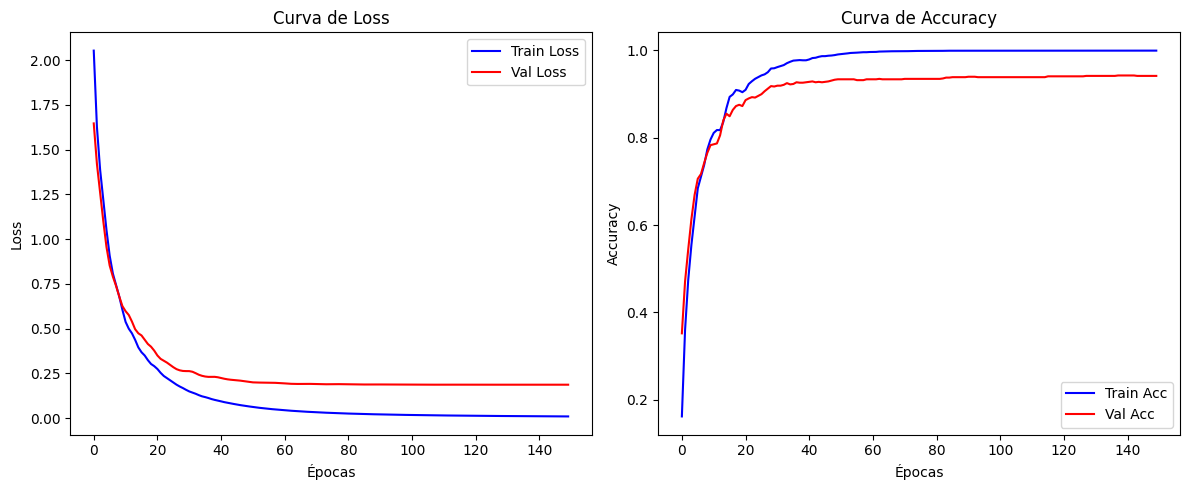


Relatório de Classificação Final:
              precision    recall  f1-score   support

   Anthropic       0.96      1.00      0.98       155
      Google       1.00      0.99      0.99       147
       Human       0.98      0.94      0.96       197
        Meta       0.95      0.88      0.91       176
     Mistral       0.85      0.91      0.88       183
      OpenAI       0.93      0.95      0.94       170

    accuracy                           0.94      1028
   macro avg       0.95      0.94      0.94      1028
weighted avg       0.94      0.94      0.94      1028



In [3]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("A treinar o Modelo DNN Final...")

bow_final = NumpyBagOfWords(max_words=3500)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = NeuralNetwork()
model_final.add(DenseLayer(input_size=3500, output_size=164))
model_final.add(ReLUActivation())
model_final.add(DenseLayer(input_size=164, output_size=num_classes))
model_final.add(SoftmaxActivation())

model_final.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=0.05))

history_final = model_final.fit(X_train_final, y_train_oh, epochs=150, val_data=(X_val_final, y_val_oh))

y_pred_final = np.argmax(model_final.forward(X_val_final, training=False), axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação Final:")
print(classification_report(y_val.values, y_pred_final, target_names=list(label_map.keys())))

model_final.save("../saved_models/DNN_final.pkl");
bow_final.save("../saved_models/DNN_bow_model.pkl")

In [4]:
print("Melhor Val Accuracy DNN:", max(history_final['val_acc']))
print("Melhor Val Loss DNN:", min(history_final['val_loss']))

Melhor Val Accuracy DNN: 0.9426070038910506
Melhor Val Loss DNN: 0.1868083799843074
